In [1]:
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from thermoift.rng_utils import get_rng
from thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics
import thermoift.PLOT_SETTINGS as ps


In [ ]:
OUTPUT_FOLDER = "XGBoost_Pbubble_OUTPUTS"
SEED          = 50015

In [2]:
df = pd.read_csv("../interfacial_results_dataset_A1.csv")

print(f"Total samples: {len(df)}")
print(f"\nP_bubble statistics:")
print(df["P_bubble"].describe())

Total samples: 19171

P_bubble statistics:
count    19171.000000
mean        38.270487
std         20.467106
min          3.181219
25%         21.341211
50%         35.985782
75%         54.333096
max        108.401596
Name: P_bubble, dtype: float64


In [3]:
target     = "P_bubble"
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13419
Testing samples:    2876
Validation samples: 2876


In [4]:
# XgBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=rng,
    n_jobs=-1)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_train_pred = xgb_model.predict(X_train)
y_test_pred  = xgb_model.predict(X_test)
y_val_pred   = xgb_model.predict(X_val)

#Metrics    
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, y_val=y_val, y_val_pred=y_val_pred)


Model Performance for P_bubble

Training Set:
  R²:   0.999684
  RMSE: 0.363526 bar
  MAE:  0.277596 bar

Test Set:
  R²:   0.999393
  RMSE: 0.504501 bar
  MAE:  0.376123 bar

Validation Set:
  R²:   0.999398
  RMSE: 0.502300 bar
  MAE:  0.376194 bar


In [5]:
results_df = pd.DataFrame({
    "idx": np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual": np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred, y_test_pred, y_val_pred]),
    "split": ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save fitted model for future use without retraining
model_path = os.path.join(OUTPUT_FOLDER, f"RF_{target}_model.joblib")
joblib.dump(xgb_model, model_path)
print(f"Model saved to: {model_path}")

Predictions saved: 19171 rows
Model saved to: XGBoost_Pbubble_OUTPUTS/RF_P_bubble_model.joblib


In [6]:
# 5-fold cross-validation
cv_r2_scores   = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')
cv_rmse_scores = -cross_val_score(xgb_model, X, y, cv=5, scoring='neg_root_mean_squared_error')

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")

Cross-Validation R² Scores:   [0.95748893 0.98988387 0.96393595 0.987491   0.96847328]
Mean CV R²:   0.973455 (+/- 0.025881)

Cross-Validation RMSE Scores: [4.16774438 1.74785351 3.71281815 2.45125328 3.9039079 ]
Mean CV RMSE: 3.196715 (+/- 1.868538)


In [7]:
# XGBoost Feature Importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=list(df[features].columns)
).sort_values(ascending=False)

print("\nXGBoost Feature Importance (gain):")
print(xgb_importance.to_string())


XGBoost Feature Importance (gain):
z_hydrogen            0.408959
pressure              0.346577
temperature           0.110859
z_carbon dioxide      0.038069
z_nitrogen            0.026680
z_carbon monoxide     0.025734
z_methane             0.016347
z_hydrogen sulfide    0.015545
z_argon               0.007433
z_oxygen              0.003798


In [ ]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="P_bubble",
    feature_importances=xgb_model.feature_importances_,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

# Plot feature importance (Linear Scale)
post.plot_feature_importance(scale="linear", color="steelblue", save_path="XGB_P_bubble_feature_importance_linear", folder=OUTPUT_FOLDER)

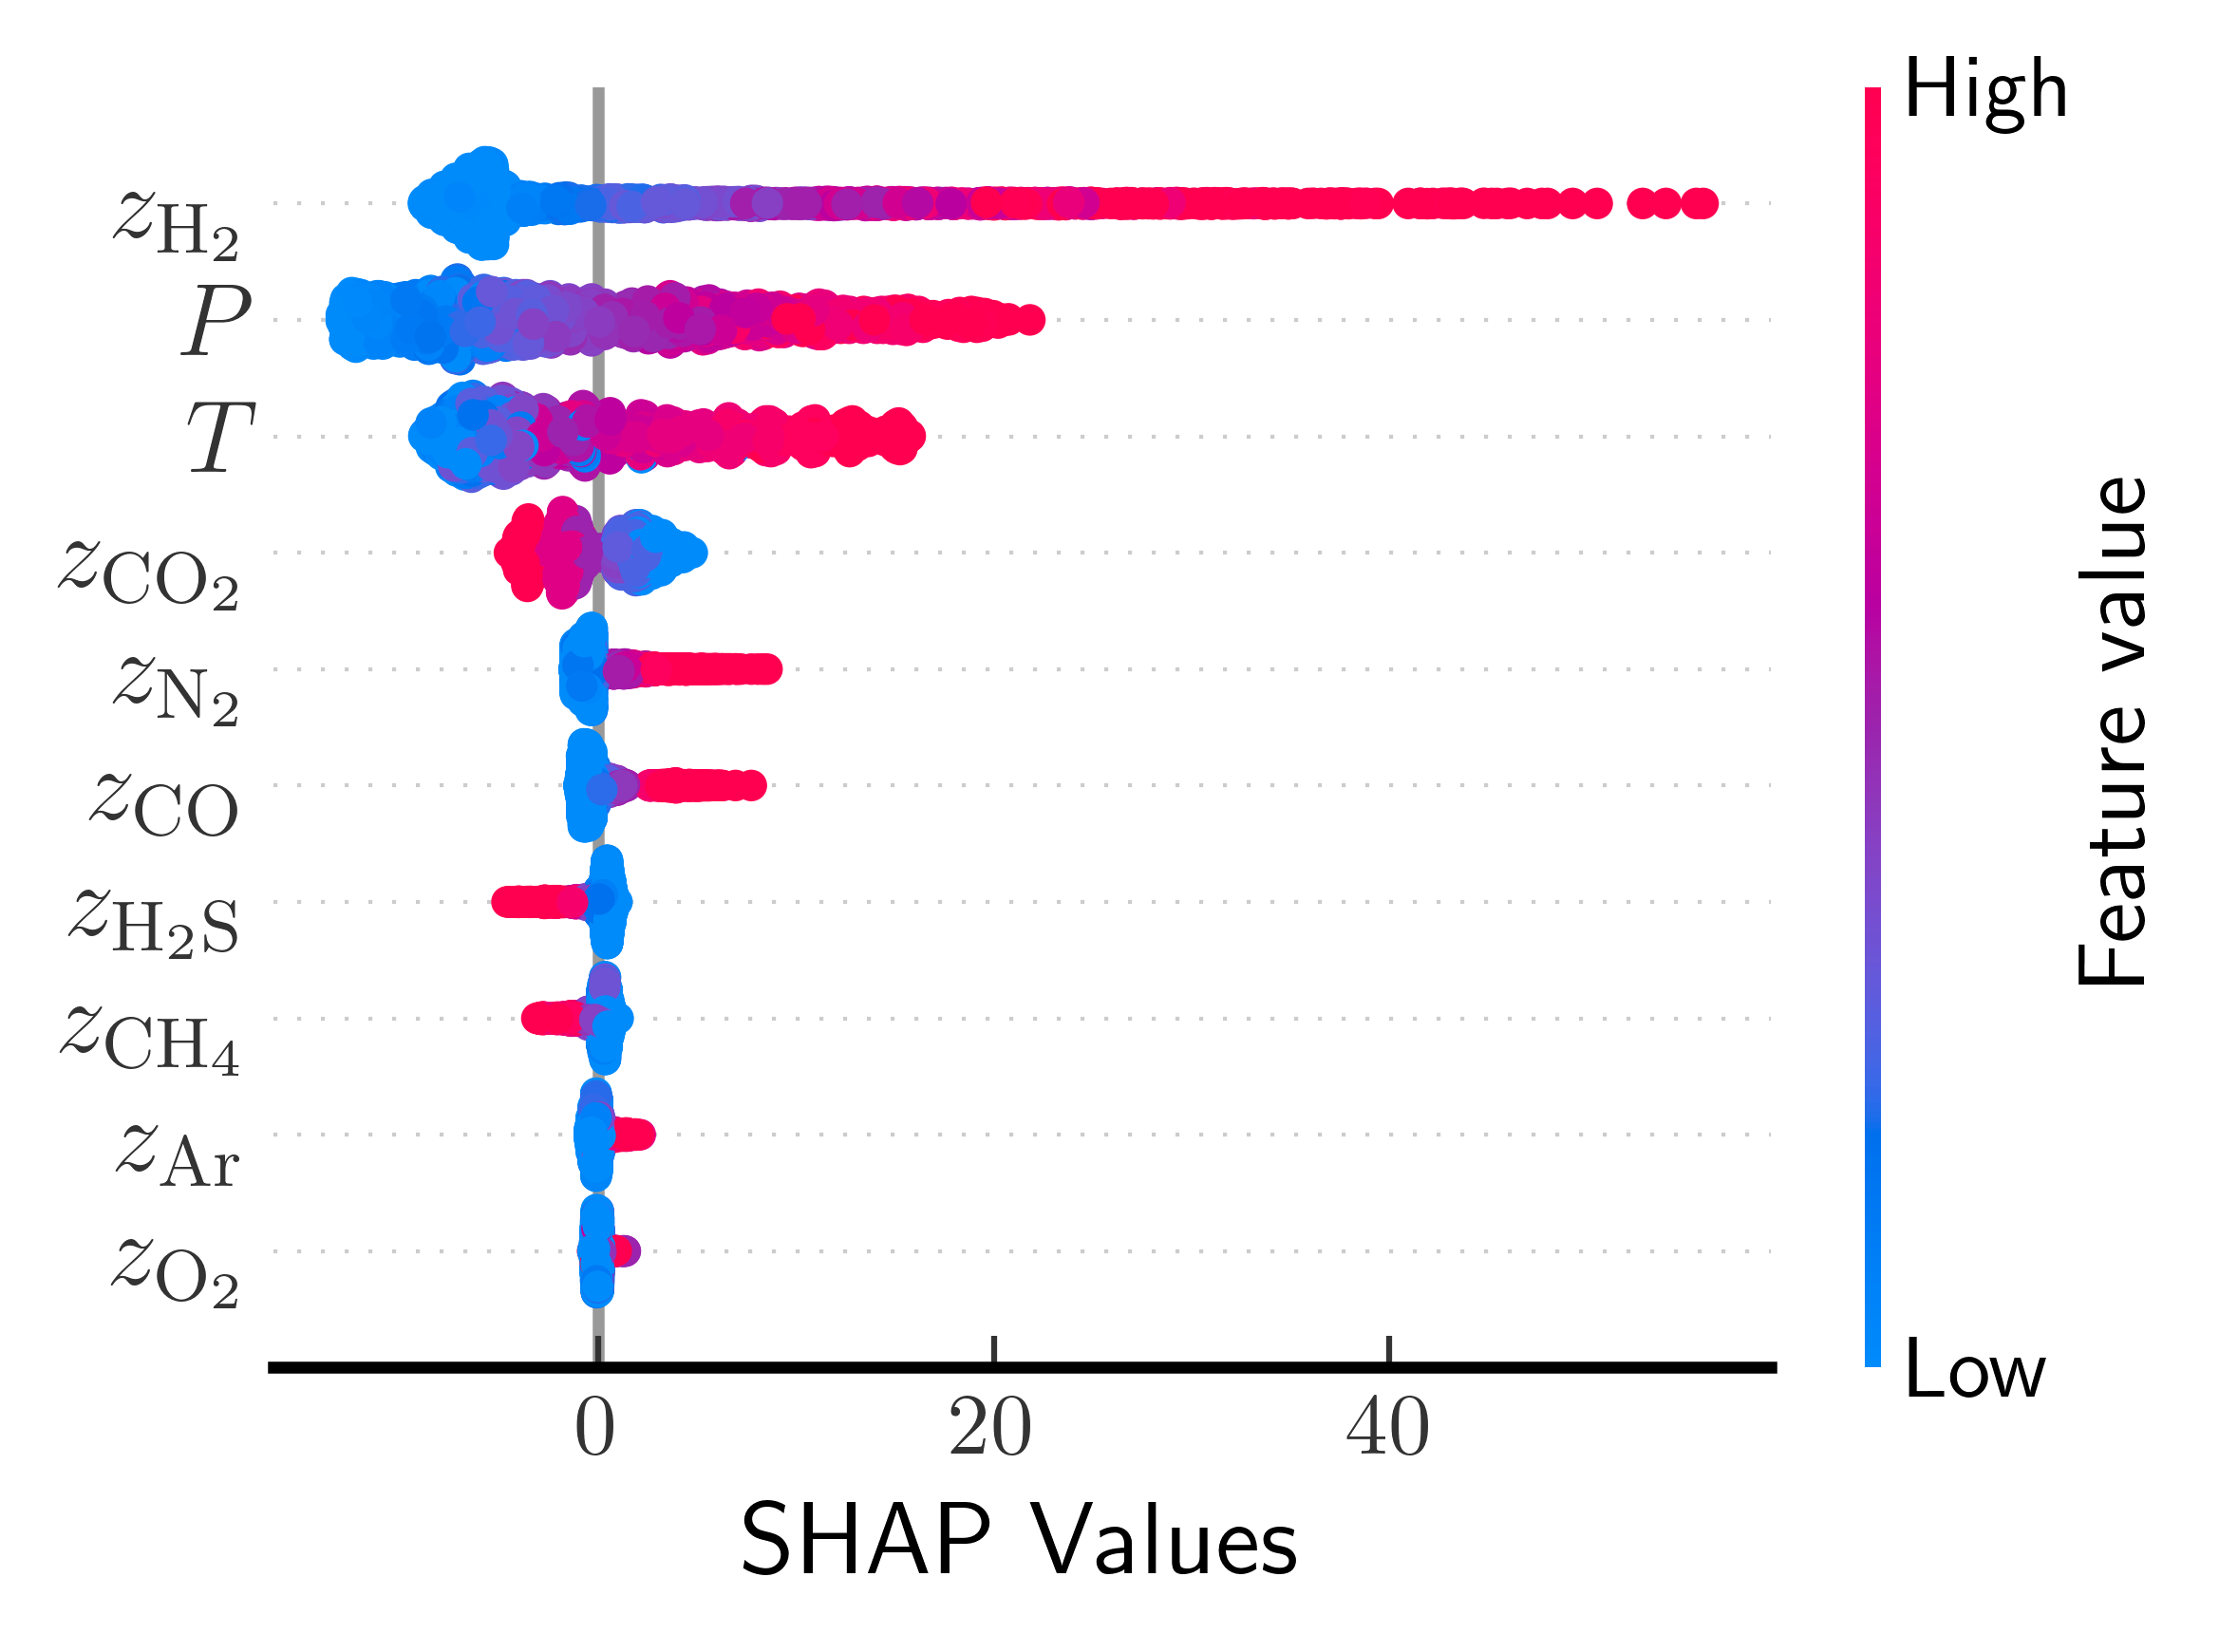

In [8]:
label_map = {
    "temperature": r"$T$",
    "pressure": r"$P$",
    "z_carbon dioxide": r"$z_{\mathrm{CO_2}}$",
    "z_hydrogen": r"$z_{\mathrm{H_2}}$",
    "z_argon": r"$z_{\mathrm{Ar}}$",
    "z_nitrogen": r"$z_{\mathrm{N_2}}$",
    "z_methane": r"$z_{\mathrm{CH_4}}$",
    "z_oxygen": r"$z_{\mathrm{O_2}}$",
    "z_carbon monoxide": r"$z_{\mathrm{CO}}$",
    "z_hydrogen sulfide": r"$z_{\mathrm{H_2S}}$",
    "P_bubble": r"$P_{\mathrm{bubble}}$",
}

# SHAP Values — XGBoost
explainer   = shap.TreeExplainer(xgb_model)       
shap_values = explainer.shap_values(X_test)         

feature_labels = [label_map.get(f, f) for f in features]
shap_df = pd.DataFrame(shap_values, columns=feature_labels)

# Plot 1: Beeswarm Summary
fig, ax = ps.plot_init()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_labels,
    show=False,
    plot_size=None)
ax = plt.gca()
ax.set_xlabel("SHAP Values")
plt.tight_layout()
ps.save_plot(fig, "XGB_P_bubble_shap_summary")
plt.show()

In [ ]:
# Parity plot
post.plot_parity(model_name="XGBoost", save_path="XGB_P_bubble_parity_plot", folder=OUTPUT_FOLDER)

In [ ]:
# Residual distribution
post.plot_residual_distribution(save_path="XGB_P_bubble_residual_distribution", folder=OUTPUT_FOLDER)

In [ ]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="XGB_P_bubble_residual_vs_predicted", folder=OUTPUT_FOLDER)

In [ ]:
post.print_summary()

# Collect and save all metrics
metrics["cv_r2_scores"]    = cv_r2_scores.tolist()
metrics["cv_r2_mean"]      = float(cv_r2_scores.mean())
metrics["cv_r2_std"]       = float(cv_r2_scores.std())
metrics["cv_rmse_scores"]  = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]    = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]     = float(cv_rmse_scores.std())
metrics["model"]           = "XGBoost"
metrics["n_estimators"]    = xgb_model.n_estimators
metrics["max_depth"]       = xgb_model.max_depth
metrics["learning_rate"]   = xgb_model.learning_rate
metrics["subsample"]       = xgb_model.subsample
metrics["colsample_bytree"]= xgb_model.colsample_bytree
metrics["features"]        = features
metrics["target"]          = target
metrics["seed"]            = SEED

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"XGB_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

In [13]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 54.79 minutes
